In [1]:
import os
os.environ["PARCELS_COMPILER"]="gcc"
os.environ["CC"]="gcc"



In [2]:
import sys
import parcels
import numpy

print("Python path:", sys.executable)
print("Parcels version:", parcels.__version__)
print("NumPy version:", numpy.__version__)

Python path: C:\Users\Trevell\miniconda3\envs\oceanparcels310\python.exe
Parcels version: 2.4.0
NumPy version: 1.26.4


In [3]:
import parcels
print(parcels.__version__)

2.4.0


In [4]:
import glob, numpy as np, xarray as xr, matplotlib.pyplot as plt
from datetime import timedelta

from parcels import (
    FieldSet, ParticleSet, ScipyParticle, JITParticle, AdvectionRK4,
    ParticleFile, Field, Variable, DiffusionUniformKh, GeographicPolar, Geographic
)

from netCDF4 import Dataset
import pandas as pd

In [5]:
import glob

# --- BASE PATHS ---
base_2009 = r"C:\Users\Trevell\OneDrive\Documents\Opakapaka\roms\2009\0.25_10_20_30_40_50_60m"
base_2010 = r"C:\Users\Trevell\OneDrive\Documents\Opakapaka\roms\2010\0.25_10_20_30_40_50_60m"

# --- MONTHS ---
months_2009 = ["06", "07", "08", "09", "10", "11", "12"]  # June–Dec
months_2010 = ["01", "02", "03"]                          # Jan–Mar (extra drift)

# --- DEPTH ---
depth = "30m"

# --- COLLECT FILES ---
roms_files_sorted = []

# 2009 files
for m in months_2009:
    pattern = rf"{base_2009}\yr_2009_{m}_depth_{depth}.nc"
    roms_files_sorted += glob.glob(pattern)

# 2010 files
for m in months_2010:
    pattern = rf"{base_2010}\yr_2010_{m}_depth_{depth}.nc"
    roms_files_sorted += glob.glob(pattern)

# --- SORT ---
roms_files_sorted = sorted(roms_files_sorted)

# --- CHECK ---
print("Files found:", len(roms_files_sorted))
for f in roms_files_sorted:
    print(f)

Files found: 10
C:\Users\Trevell\OneDrive\Documents\Opakapaka\roms\2009\0.25_10_20_30_40_50_60m\yr_2009_06_depth_30m.nc
C:\Users\Trevell\OneDrive\Documents\Opakapaka\roms\2009\0.25_10_20_30_40_50_60m\yr_2009_07_depth_30m.nc
C:\Users\Trevell\OneDrive\Documents\Opakapaka\roms\2009\0.25_10_20_30_40_50_60m\yr_2009_08_depth_30m.nc
C:\Users\Trevell\OneDrive\Documents\Opakapaka\roms\2009\0.25_10_20_30_40_50_60m\yr_2009_09_depth_30m.nc
C:\Users\Trevell\OneDrive\Documents\Opakapaka\roms\2009\0.25_10_20_30_40_50_60m\yr_2009_10_depth_30m.nc
C:\Users\Trevell\OneDrive\Documents\Opakapaka\roms\2009\0.25_10_20_30_40_50_60m\yr_2009_11_depth_30m.nc
C:\Users\Trevell\OneDrive\Documents\Opakapaka\roms\2009\0.25_10_20_30_40_50_60m\yr_2009_12_depth_30m.nc
C:\Users\Trevell\OneDrive\Documents\Opakapaka\roms\2010\0.25_10_20_30_40_50_60m\yr_2010_01_depth_30m.nc
C:\Users\Trevell\OneDrive\Documents\Opakapaka\roms\2010\0.25_10_20_30_40_50_60m\yr_2010_02_depth_30m.nc
C:\Users\Trevell\OneDrive\Documents\Opakapaka\ro

In [6]:
from parcels import FieldSet

# Make sure this exists (fails fast with a clear message)
assert "roms_files_sorted" in globals(), "roms_files_sorted is not defined. Run the file-list cell first."
assert len(roms_files_sorted) > 0, "roms_files_sorted is empty. Check your file paths."

# Use the first file as the grid/coord source (works for your monthly files)
roms_file = roms_files_sorted[0]

variables = {"U": "u", "V": "v"}
dimensions = {
    "U": {"lon": "longitude", "lat": "latitude", "time": "time", "depth": "depth"},
    "V": {"lon": "longitude", "lat": "latitude", "time": "time", "depth": "depth"},
}

filenames = {
    "U": {"lon": roms_file, "lat": roms_file, "depth": roms_file, "data": roms_files_sorted, "time": roms_files_sorted},
    "V": {"lon": roms_file, "lat": roms_file, "depth": roms_file, "data": roms_files_sorted, "time": roms_files_sorted},
}

fieldset = FieldSet.from_netcdf(
    filenames, variables, dimensions,
    mesh="spherical",
    allow_time_extrapolation=False
)

print("Depth levels:", fieldset.U.depth)
print("Time start:", fieldset.U.grid.time[0])
print("Time end:", fieldset.U.grid.time[-1])
print("Using ROMS files:")
for f in roms_files_sorted:
    print("  ", f)

Depth levels: [30.]
Time start: 0.0
Time end: 26179200.0
Using ROMS files:
   C:\Users\Trevell\OneDrive\Documents\Opakapaka\roms\2009\0.25_10_20_30_40_50_60m\yr_2009_06_depth_30m.nc
   C:\Users\Trevell\OneDrive\Documents\Opakapaka\roms\2009\0.25_10_20_30_40_50_60m\yr_2009_07_depth_30m.nc
   C:\Users\Trevell\OneDrive\Documents\Opakapaka\roms\2009\0.25_10_20_30_40_50_60m\yr_2009_08_depth_30m.nc
   C:\Users\Trevell\OneDrive\Documents\Opakapaka\roms\2009\0.25_10_20_30_40_50_60m\yr_2009_09_depth_30m.nc
   C:\Users\Trevell\OneDrive\Documents\Opakapaka\roms\2009\0.25_10_20_30_40_50_60m\yr_2009_10_depth_30m.nc
   C:\Users\Trevell\OneDrive\Documents\Opakapaka\roms\2009\0.25_10_20_30_40_50_60m\yr_2009_11_depth_30m.nc
   C:\Users\Trevell\OneDrive\Documents\Opakapaka\roms\2009\0.25_10_20_30_40_50_60m\yr_2009_12_depth_30m.nc
   C:\Users\Trevell\OneDrive\Documents\Opakapaka\roms\2010\0.25_10_20_30_40_50_60m\yr_2010_01_depth_30m.nc
   C:\Users\Trevell\OneDrive\Documents\Opakapaka\roms\2010\0.25_10_20

In [7]:
TOP_LEVEL = 30.0
fieldset.add_constant("TOP_LEVEL", TOP_LEVEL)
print("Running simulation at depth:", fieldset.TOP_LEVEL, "meters")

Running simulation at depth: 30.0 meters


In [8]:
import glob
import xarray as xr

base_path = r"C:\Users\Trevell\OneDrive\Documents\Opakapaka\roms\2009\0.25_10_20_30_40_50_60m"

files = sorted(glob.glob(base_path + r"\yr_2009_06_depth_*.nc"))

print("Checking depth inside each file...\n")

for f in files:
    ds = xr.open_dataset(f)
    depth_vals = ds["depth"].values
    print(f.split("\\")[-1], "→ depth =", depth_vals)

Checking depth inside each file...

yr_2009_06_depth_0p25m.nc → depth = [0.25]
yr_2009_06_depth_10m.nc → depth = [10.]
yr_2009_06_depth_20m.nc → depth = [20.]
yr_2009_06_depth_30m.nc → depth = [30.]
yr_2009_06_depth_40m.nc → depth = [50.]
yr_2009_06_depth_50m.nc → depth = [50.]
yr_2009_06_depth_60m.nc → depth = [50.]


In [9]:
import xarray as xr
import numpy as np

def all_times_from_files(files, time_name="time"):
    times = []
    for fp in files:
        with xr.open_dataset(fp, decode_times=True) as ds:
            t = ds[time_name].values
            t = np.atleast_1d(t)
            times.append(t)
    return np.concatenate(times)

all_times = all_times_from_files(roms_files_sorted)


print("First timestamp:", all_times[0])
print("Last timestamp:", all_times[-1])

First timestamp: 2009-06-02T00:00:00.000000000
Last timestamp: 2010-04-01T00:00:00.000000000


In [10]:
import numpy as np

# Parcels time is in SECONDS since a time origin
tsec = np.asarray(fieldset.U.grid.time, dtype=float)

# --- robustly extract a usable datetime64 origin ---
origin_obj = fieldset.U.grid.time_origin
print("time_origin raw type:", type(origin_obj))
print("time_origin raw value:", origin_obj)

# Try common Parcels shapes
if isinstance(origin_obj, np.datetime64):
    origin64 = origin_obj
elif isinstance(origin_obj, str):
    origin64 = np.datetime64(origin_obj)
elif hasattr(origin_obj, "origin"):          # e.g., TimeConverter(origin=...)
    origin64 = np.datetime64(origin_obj.origin)
elif hasattr(origin_obj, "time_origin"):     # alternative attribute name
    origin64 = np.datetime64(origin_obj.time_origin)
else:
    # last resort (works if it's a python datetime)
    origin64 = np.datetime64(origin_obj)

# Convert seconds -> datetime64 so we can mask by dates
tsec_int = np.round(tsec).astype("int64")  # safer than float -> timedelta directly
tdt = origin64 + tsec_int.astype("timedelta64[s]")

YEAR = 2009
start_target = np.datetime64(f"{YEAR}-06-01T00:00:00")
end_target   = np.datetime64(f"{YEAR}-10-01T00:00:00")  # June..Sep (end is Oct 1)

mask_win = (tdt >= start_target) & (tdt < end_target)

print("Times in window:", int(mask_win.sum()))
print("Window start dt:", tdt[mask_win][0] if mask_win.any() else None)
print("Window end dt  :", tdt[mask_win][-1] if mask_win.any() else None)

if not mask_win.any():
    raise ValueError("No timestamps found in June–Sep window. (Likely your FieldSet only includes 1 month.)")

# IMPORTANT: start_time/end_time must be SECONDS (for Parcels)
start_time = float(tsec[mask_win][0])
end_time   = float(tsec[mask_win][-1])

print("Chosen start_time (sec):", start_time)
print("Chosen end_time   (sec):", end_time)
print(" number of days/runtime days:", (end_time - start_time) / 86400.0)

time_origin raw type: <class 'parcels.tools.converters.TimeConverter'>
time_origin raw value: 2009-06-02T00:00:00.000000000
Times in window: 947
Window start dt: 2009-06-02T00:00:00.000000000
Window end dt  : 2009-09-30T21:00:00.000000000
Chosen start_time (sec): 0.0
Chosen end_time   (sec): 10443600.0
runtime days: 120.875


In [11]:
import numpy as np

t = fieldset.U.grid.time
print("t0 sec:", t[0], "tN sec:", t[-1], "days:", (t[-1]-t[0])/86400)

# If you have the datetime array you used earlier:
print("min dt:", all_times.min())
print("max dt:", all_times.max())
print("unique months:", np.unique(all_times.astype("datetime64[M]")))

t0 sec: 0.0 tN sec: 26179200.0 days: 303.0
min dt: 2009-06-02T00:00:00.000000000
max dt: 2010-04-01T00:00:00.000000000
unique months: ['2009-06' '2009-07' '2009-08' '2009-09' '2009-10' '2009-11' '2009-12'
 '2010-01' '2010-02' '2010-03' '2010-04']


In [12]:

AGG_FACTOR = 5          # "convert resolution by factor of 5"
PR_THRESH  = 0.25       # below this -> 0 particles
WEIGHT_MULT = 10 
Kh = 10.0  # horizontal diffusion [m^2/s]
# particles = round(PR * 10)


In [16]:
fieldset = FieldSet.from_netcdf(filenames, variables, dimensions,interp_method={'U': 'freeslip', 'V': 'freeslip'})

# In[12]:

file_path_fine = r"C:\Users\Trevell\OneDrive\Documents\Opakapaka\roms\2016\60_100m\2f5b575911fddfb03f363df36a50275a.nc"
lon_grid = np.asarray(fieldset.U.grid.lon)
lat_grid = np.asarray(fieldset.U.grid.lat)

if lon_grid.ndim == 1 and lat_grid.ndim == 1:
    # lon[x], lat[y]  -> data must be [t, y, x]
    Kh_z = np.full((1, lat_grid.size, lon_grid.size), Kh, dtype=np.float32)
    Kh_m = np.full((1, lat_grid.size, lon_grid.size), Kh, dtype=np.float32)

    fieldset.add_field(Field("Kh_zonal", Kh_z, lon=lon_grid, lat=lat_grid, mesh="spherical"))
    fieldset.add_field(Field("Kh_meridional", Kh_m, lon=lon_grid, lat=lat_grid, mesh="spherical"))

else:
    # lon[y,x], lat[y,x] -> data must be [t, y, x] matching that grid
    Kh_z = np.full((1,) + lon_grid.shape, Kh, dtype=np.float32)
    Kh_m = np.full((1,) + lon_grid.shape, Kh, dtype=np.float32)

    fieldset.add_field(Field("Kh_zonal", Kh_z, lon=lon_grid, lat=lat_grid, mesh="spherical", transpose=True))
    fieldset.add_field(Field("Kh_meridional", Kh_m, lon=lon_grid, lat=lat_grid, mesh="spherical", transpose=True))


file_path_fine = roms_files_sorted[0]   # uses the same year/month/depth file
print("USING file_path_fine:", file_path_fine)


from parcels import Field

habitat_field = Field(
    name="habitat",
    data=habitat_mask,
    lon=lon_bathy,
    lat=lat_bathy
)

fieldset.add_field(habitat_field)

print("Habitat field added to fieldset")

def make_landmask(fielddata):
    """Returns landmask where land = 1 and ocean = 0
    fielddata is a netcdf file.
    """
    datafile = Dataset(fielddata)

    landmask = datafile.variables['u'][0, 0]
    landmask = np.ma.masked_invalid(landmask) #remove Nas? 
    landmask = landmask.mask.astype('int')

    return landmask

#


landmask_fine = make_landmask(file_path_fine)


# In[28]:
def get_coastal_nodes(landmask):
    """Function that detects the coastal nodes, i.e. the ocean nodes directly
    next to land. Computes the Laplacian of landmask.

    - landmask: the land mask built using `make_landmask`, where land cell = 1
                and ocean cell = 0.

    Output: 2D array array containing the coastal nodes, the coastal nodes are
            equal to one, and the rest is zero.
    """
    mask_lap = np.roll(landmask, -1, axis=0) + np.roll(landmask, 1, axis=0)
    mask_lap += np.roll(landmask, -1, axis=1) + np.roll(landmask, 1, axis=1)
    mask_lap -= 4*landmask
    coastal = np.ma.masked_array(landmask, mask_lap > 0)
    coastal = coastal.mask.astype('int')

    return coastal

def get_shore_nodes(landmask):
    """Function that detects the shore nodes, i.e. the land nodes directly
    next to the ocean. Computes the Laplacian of landmask.

    - landmask: the land mask built using `make_landmask`, where land cell = 1
                and ocean cell = 0.

    Output: 2D array array containing the shore nodes, the shore nodes are
            equal to one, and the rest is zero.
    """
    mask_lap = np.roll(landmask, -1, axis=0) + np.roll(landmask, 1, axis=0)
    mask_lap += np.roll(landmask, -1, axis=1) + np.roll(landmask, 1, axis=1)
    mask_lap -= 4*landmask
    shore = np.ma.masked_array(landmask, mask_lap < 0)
    shore = shore.mask.astype('int')

    return shore

# In[13]:

def get_coastal_nodes_diagonal(landmask):
    """Function that detects the coastal nodes, i.e. the ocean nodes where 
    one of the 8 nearest nodes is land. Computes the Laplacian of landmask
    and the Laplacian of the 45 degree rotated landmask.

    - landmask: the land mask built using `make_landmask`, where land cell = 1
                and ocean cell = 0.

    Output: 2D array array containing the coastal nodes, the coastal nodes are
            equal to one, and the rest is zero.
    """
    mask_lap = np.roll(landmask, -1, axis=0) + np.roll(landmask, 1, axis=0)
    mask_lap += np.roll(landmask, -1, axis=1) + np.roll(landmask, 1, axis=1)
    mask_lap += np.roll(landmask, (-1,1), axis=(0,1)) + np.roll(landmask, (1, 1), axis=(0,1))
    mask_lap += np.roll(landmask, (-1,-1), axis=(0,1)) + np.roll(landmask, (1, -1), axis=(0,1))
    mask_lap -= 8*landmask
    coastal = np.ma.masked_array(landmask, mask_lap > 0)
    coastal = coastal.mask.astype('int')
    
    return coastal
    
def get_shore_nodes_diagonal(landmask):
    """Function that detects the shore nodes, i.e. the land nodes where 
    one of the 8 nearest nodes is ocean. Computes the Laplacian of landmask 
    and the Laplacian of the 45 degree rotated landmask.

    - landmask: the land mask built using `make_landmask`, where land cell = 1
                and ocean cell = 0.

    Output: 2D array array containing the shore nodes, the shore nodes are
            equal to one, and the rest is zero.
    """
    mask_lap = np.roll(landmask, -1, axis=0) + np.roll(landmask, 1, axis=0)
    mask_lap += np.roll(landmask, -1, axis=1) + np.roll(landmask, 1, axis=1)
    mask_lap += np.roll(landmask, (-1,1), axis=(0,1)) + np.roll(landmask, (1, 1), axis=(0,1))
    mask_lap += np.roll(landmask, (-1,-1), axis=(0,1)) + np.roll(landmask, (1, -1), axis=(0,1))
    mask_lap -= 8*landmask
    shore = np.ma.masked_array(landmask, mask_lap < 0)
    shore = shore.mask.astype('int')

    return shore
#
coastal_fine = get_coastal_nodes_diagonal(landmask_fine)
shore_fine = get_shore_nodes_diagonal(landmask_fine)

#
def create_displacement_field(landmask, double_cell=False):
    """Function that creates a displacement field 1 m/s away from the shore.

    - landmask: the land mask dUilt using `make_landmask`.
    - double_cell: Boolean for determining if you want a double cell.
      Default set to False.

    Output: two 2D arrays, one for each camponent of the velocity.
    """
    shore = get_shore_nodes(landmask)
    shore_d = get_shore_nodes_diagonal(landmask) # bordering ocean directly and diagonally
    shore_c = shore_d - shore                    # corner nodes that only border ocean diagonally
    
    Ly = np.roll(landmask, -1, axis=0) - np.roll(landmask, 1, axis=0) # Simple derivative
    Lx = np.roll(landmask, -1, axis=1) - np.roll(landmask, 1, axis=1)
    
    Ly_c = np.roll(landmask, -1, axis=0) - np.roll(landmask, 1, axis=0)
    Ly_c += np.roll(landmask, (-1,-1), axis=(0,1)) + np.roll(landmask, (-1,1), axis=(0,1)) # Include y-component of diagonal neighbours
    Ly_c += - np.roll(landmask, (1,-1), axis=(0,1)) - np.roll(landmask, (1,1), axis=(0,1))
    
    Lx_c = np.roll(landmask, -1, axis=1) - np.roll(landmask, 1, axis=1)
    Lx_c += np.roll(landmask, (-1,-1), axis=(1,0)) + np.roll(landmask, (-1,1), axis=(1,0)) # Include x-component of diagonal neighbours
    Lx_c += - np.roll(landmask, (1,-1), axis=(1,0)) - np.roll(landmask, (1,1), axis=(1,0))
    
    v_x = -Lx*(shore)
    v_y = -Ly*(shore)
    
    v_x_c = -Lx_c*(shore_c)
    v_y_c = -Ly_c*(shore_c)
    
    v_x = v_x + v_x_c
    v_y = v_y + v_y_c

    magnitude = np.sqrt(v_y**2 + v_x**2)
    # the coastal nodes between land create a problem. Magnitude there is zero
    # I force it to be 1 to avoid problems when normalizing.
    ny, nx = np.where(magnitude == 0)
    magnitude[ny, nx] = 1

    v_x = v_x/magnitude
    v_y = v_y/magnitude

    return v_x, v_y



##
v_x_f, v_y_f = create_displacement_field(landmask_fine)
#

def distance_to_shore(landmask, dx=1):
    """Function that computes the distance to the shore. It is based in the
    the `get_coastal_nodes` algorithm.

    - landmask: the land mask dUilt using `make_landmask` function.
    - dx: the grid cell dimension. This is a crude approxsimation of the real
    distance (be careful).

    Output: 2D array containing the distances from shore.
    """
    ci = get_coastal_nodes(landmask) # direct neighbours
    dist = ci*dx                     # 1 dx away
    
    ci_d = get_coastal_nodes_diagonal(landmask) # diagonal neighbours
    dist_d = (ci_d - ci)*np.sqrt(2*dx**2)       # sqrt(2) dx away
        
    return dist+dist_d

#
d_2_s_f = distance_to_shore(landmask_fine)

#
def set_displacement(particle, fieldset, time):
    """Clamp to safe inner bounds before sampling static fields."""
    # use SAFE_* + EPS to stay one full cell in
    if particle.lon <= fieldset.SAFE_LON_MIN:
        particle.lon = fieldset.SAFE_LON_MIN + fieldset.LON_EPS
    if particle.lon >= fieldset.SAFE_LON_MAX:
        particle.lon = fieldset.SAFE_LON_MAX - fieldset.LON_EPS
    if particle.lat <= fieldset.SAFE_LAT_MIN:
        particle.lat = fieldset.SAFE_LAT_MIN + fieldset.LAT_EPS
    if particle.lat >= fieldset.SAFE_LAT_MAX:
        particle.lat = fieldset.SAFE_LAT_MAX - fieldset.LAT_EPS

    particle.d2s = fieldset.distance2shore_fine[time, particle.depth, particle.lat, particle.lon]

    if particle.d2s < fieldset.shore_threshold:
        particle.dU = fieldset.dispUF[time, particle.depth, particle.lat, particle.lon]
        particle.dV = fieldset.dispVF[time, particle.depth, particle.lat, particle.lon]
    else:
        particle.dU = 0.0
        particle.dV = 0.0



##
def displace(particle, fieldset, time):    
    if  particle.d2s < 0.5:
        particle.lon += particle.dU*particle.dt
        particle.lat += particle.dV*particle.dt
##
u_displacement_f = v_x_f
v_displacement_f = v_y_f
#
fieldset.add_field(Field('dispUF', data=u_displacement_f,
                         lon=fieldset.U.grid.lon, lat=fieldset.U.grid.lat,
                         mesh='spherical')) #have to index to choose which field we want to base it off of; 1 is choosing coarser

fieldset.add_field(Field('dispVF', data=v_displacement_f,
                         lon=fieldset.U.grid.lon, lat=fieldset.U.grid.lat,
                         mesh='spherical'))
fieldset.dispUF.units = GeographicPolar()
fieldset.dispVF.units = Geographic()
fieldset.add_field(Field('landmask_fine', landmask_fine,
                         lon=fieldset.U.grid.lon, lat=fieldset.U.grid.lat,
                         mesh='spherical'))
fieldset.add_field(Field('distance2shore_fine', d_2_s_f,
                         lon=fieldset.U.grid.lon, lat=fieldset.U.grid.lat,
                         mesh='spherical'))
from parcels import JITParticle, Variable



#look at this warning

USING file_path_fine: C:\Users\Trevell\OneDrive\Documents\Opakapaka\roms\2009\0.25_10_20_30_40_50_60m\yr_2009_06_depth_30m.nc
Habitat field added to fieldset


In [ ]:
print("depth exists:", "depth" in globals())
print("lon_bathy exists:", "lon_bathy" in globals())
print("lat_bathy exists:", "lat_bathy" in globals())
print("habitat_mask exists:", "habitat_mask" in globals())

In [14]:
# ============================================================
# LOAD BATHYMETRY (ETOPO)
# ============================================================

import rioxarray as rxr

bathy_path = r"C:\Users\Trevell\OneDrive\Documents\Opakapaka\roms\ETOPO_2022 (Bedrock; 15 arcseconds).tiff"

bathy = rxr.open_rasterio(bathy_path)

depth = bathy.values[0]
lon_bathy = bathy.x.values
lat_bathy = bathy.y.values

print("Bathymetry loaded")
print("Depth grid shape:", depth.shape)

Bathymetry loaded
Depth grid shape: (1440, 2400)


In [15]:
# ============================================================
# BUILD OPakapaka SETTLEMENT HABITAT
# (40–60 m depth + 4 km buffer)
# ============================================================

from scipy.ndimage import binary_dilation
import numpy as np

# select 40–60 m depth band
habitat_band = (depth <= -40) & (depth >= -60)

# convert 4 km to grid cells
#check on the 1.8 (0.463) DOUBLE CHECK
km_per_cell = 1.8
buffer_cells = int(4 / km_per_cell)

# expand habitat
habitat_buffered = binary_dilation(habitat_band, iterations=buffer_cells)

habitat_mask = habitat_buffered.astype(np.int32)

print("Settlement habitat mask created")
print("Habitat cells:", habitat_mask.sum())

Settlement habitat mask created
Habitat cells: 17780


In [17]:
# ============================================================
# DEFINE HAWAII ISLAND POLYGONS
# ============================================================

from shapely.geometry import Polygon

island_polygons = {

   "Kauai": Polygon([
    (-159.70, 22.30),
    (-159.20, 22.30),
    (-159.20, 21.85),
    (-159.70, 21.85)
]),

"Niihau": Polygon([
    (-160.30, 22.05),
    (-159.95, 22.05),
    (-159.95, 21.75),
    (-160.30, 21.75)
]),

"Kaula": Polygon([
    (-160.75, 21.72),
    (-160.45, 21.72),
    (-160.45, 21.50),
    (-160.75, 21.50)
]),
    "Oahu": Polygon([
        (-158.40, 21.80),
        (-157.60, 21.80),
        (-157.60, 21.10),
        (-158.40, 21.10)
    ]),

    "Maui_Nui": Polygon([
    (-157.4, 21.2),
    (-156.0, 21.2),
    (-156.0, 20.4),
    (-157.4, 20.4)
]),

"Hawaii": Polygon([
    (-156.0, 20.3),
    (-154.7, 20.3),
    (-154.7, 18.9),
    (-156.0, 18.9)
]),
}

print("Island polygons created:", list(island_polygons.keys()))
for a_name, a_poly in island_polygons.items():
    for b_name, b_poly in island_polygons.items():
        if a_name < b_name:
            if a_poly.intersects(b_poly):
                print(f"Overlap: {a_name} with {b_name}")

Island polygons created: ['Kauai', 'Niihau', 'Kaula', 'Oahu', 'Maui_Nui', 'Hawaii']


In [19]:
from shapely.geometry import Point

region_masks = {}

LON2, LAT2 = np.meshgrid(lon_bathy, lat_bathy)

for region_name, poly in island_polygons.items():
    inside_poly = np.zeros_like(habitat_mask, dtype=np.int32)

    for j in range(LAT2.shape[0]):
        for i in range(LON2.shape[1]):
            p = Point(LON2[j, i], LAT2[j, i])
            if p.within(poly):
                inside_poly[j, i] = 1

    # combine polygon + habitat
    region_mask = ((habitat_mask == 1) & (inside_poly == 1)).astype(np.int32)

    region_masks[region_name] = region_mask
    print(region_name, "cells:", region_mask.sum())

Kauai cells: 1256
Niihau cells: 944
Kaula cells: 106
Oahu cells: 2056
Maui_Nui cells: 5780
Hawaii cells: 3066


In [20]:
from parcels import Field

for region_name, region_mask in region_masks.items():
    field_name = f"mask_{region_name}"

    mask_3d = region_mask[np.newaxis, :, :]

    fieldset.add_field(Field(
        name=field_name,
        data=mask_3d,
        lon=lon_bathy,
        lat=lat_bathy,
        mesh="spherical"
    ))

    print("Added:", field_name)

Added: mask_Kauai
Added: mask_Niihau
Added: mask_Kaula
Added: mask_Oahu
Added: mask_Maui_Nui
Added: mask_Hawaii


In [21]:
print(hasattr(fieldset, "mask_Kaula"))
print(hasattr(fieldset, "mask_Kauai"))
print(hasattr(fieldset, "mask_Niihau"))
print([name for name in dir(fieldset) if name.startswith("mask_")])

True
True
True
['mask_Hawaii', 'mask_Kauai', 'mask_Kaula', 'mask_Maui_Nui', 'mask_Niihau', 'mask_Oahu']


In [22]:
# ============================================================
# INITIALIZE SETTLEMENT COUNTER
# ============================================================

fieldset.add_constant("settlement_counter", 0)

print("Settlement counter initialized")

Settlement counter initialized


In [24]:
# Quick domain bounds 
import numpy as np
LON_MIN, LON_MAX = float(np.min(fieldset.U.grid.lon)), float(np.max(fieldset.U.grid.lon))
LAT_MIN, LAT_MAX = float(np.min(fieldset.U.grid.lat)), float(np.max(fieldset.U.grid.lat))
print("Domain lon:", LON_MIN, "→", LON_MAX, " | lat:", LAT_MIN, "→", LAT_MAX)

# Detect available depth levels 
zlevels = np.asarray(fieldset.U.depth if hasattr(fieldset.U, "depth") else fieldset.U.grid.depth, dtype=float)
zlevels_sorted = np.sort(zlevels)
print("Depth levels:", zlevels_sorted)
TOP_LEVEL = float(zlevels_sorted[0])  # e.g., 50.0 for your 60–100 m data


Domain lon: -163.83070373535156 → -152.51930236816406  | lat: 17.0184326171875 → 23.982389450073242
Depth levels: [30.]


In [25]:
print("Kh_zonal:", fieldset.Kh_zonal)
print("Kh_meridional:", fieldset.Kh_meridional)


Kh_zonal: <parcels.field.Field object at 0x000002660175A560>
Kh_meridional: <parcels.field.Field object at 0x00000266015481C0>


In [26]:
# --- depth info from ROMS and safe constants ---

# Get all the depth levels that the ocean model uses.
# Think of this as a list of water depths where the model can place particles.
zlevels = np.asarray(getattr(fieldset.U, "depth", fieldset.U.grid.depth), dtype=float)

# Sort those depth values from shallowest to deepest.
# This makes it easy to grab the top (shallowest) and bottom (deepest) depths.
zlevels_sorted = np.sort(zlevels)

# Save the shallowest depth from the model.
# We use this so we know how close to the "surface" we’re allowed to start.
DEPTH_MIN = float(zlevels_sorted[0])  # e.g., 60.0

# Save the deepest depth from the model.
# This tells us how far down the model goes, so we don’t try to go past it.
DEPTH_MAX = float(zlevels_sorted[-1])  # e.g., 100.0

# Pick the shallowest depth as the depth where things will drift.
# This is used to put eggs/particles as close to the surface as the model allows.
DRIFT_DEPTH = DEPTH_MIN

# Store these values inside the fieldset so all parts of the code can use them.
# This keeps everything consistent and avoids hard-coding numbers in many places.
fieldset.add_constant("DEPTH_MIN",   DEPTH_MIN)
fieldset.add_constant("DEPTH_MAX",   DEPTH_MAX)
fieldset.add_constant("DRIFT_DEPTH", DRIFT_DEPTH)

# Use the drift depth as the "top level" for particles.
# This means eggs start at a depth that is valid for the model instead of an
# unrealistic depth that could crash the run.
TOP_LEVEL = DRIFT_DEPTH
fieldset.add_constant("TOP_LEVEL", TOP_LEVEL)


In [27]:
# --- Edge nudges so particles don't sit exactly on the boundary ---
import numpy as np

# Grab all the longitude (left–right) positions from the model grid
LON_arr = np.asarray(fieldset.U.grid.lon, dtype=float)

# Grab all the latitude (up–down) positions from the model grid
LAT_arr = np.asarray(fieldset.U.grid.lat, dtype=float)

# Estimate a "typical" spacing between longitudes.
# This tells us roughly how far apart the grid points are left–to–right.
LON_DX = float(np.nanmedian(np.abs(np.diff(LON_arr))))

# Estimate a "typical" spacing between latitudes.
# This tells us roughly how far apart the grid points are up–down.
LAT_DY = float(np.nanmedian(np.abs(np.diff(LAT_arr))))

# Store a small nudge distance in longitude (1/4 of a grid step).
# We use this to push particles slightly away from the very edge,
# so they don't sit exactly on the border and cause "out of bounds" problems.
fieldset.add_constant("LON_EPS", 0.25 * LON_DX)

# Store a small nudge distance in latitude (1/4 of a grid step).
# Same idea: gently move particles away from the top/bottom borders
# so the model runs more safely.
fieldset.add_constant("LAT_EPS", 0.25 * LAT_DY)

# Find the shallowest depth level in the model.
# We save this so we know the highest (closest to surface) depth we can use.
fieldset.add_constant(
    "DEPTH_MIN",
    float(np.min(getattr(fieldset.U, "depth", fieldset.U.grid.depth)))
)

# Find the deepest depth level in the model.
# We save this so we know the lowest depth we can go to without breaking the model.
fieldset.add_constant(
    "DEPTH_MAX",
    float(np.max(getattr(fieldset.U, "depth", fieldset.U.grid.depth)))
)


In [28]:
# --- Make a clean list of Opakapaka release locations that are only in the ocean ---

import numpy as np, pandas as pd, xarray as xr

# A) Load the habitat CSV file
# This file lists possible release spots for Opakapaka, with their longitude, latitude, and weights.
release_csv = r"C:\Users\Trevell\OneDrive\Documents\Opakapaka\roms\2015\60_100m\Opakapaka_General_Habitat_PB.csv"
df = pd.read_csv(release_csv, header=None, names=["id", "lon", "lat", "weight"])

# Turn the longitude and latitude columns into regular arrays so we can work with them easily.
release_lons_raw = df["lon"].to_numpy(dtype=float)
release_lats_raw = df["lat"].to_numpy(dtype=float)

# Print how many total points we started with.
print(f"Loaded {release_lons_raw.size:,} candidate release points from CSV")

# B) Remove any points that fall outside the ocean model area (the ROMS grid)
# This makes sure we only keep points inside the part of the ocean your model covers.
LON_MIN, LON_MAX = float(np.min(fieldset.U.grid.lon)), float(np.max(fieldset.U.grid.lon))
LAT_MIN, LAT_MAX = float(np.min(fieldset.U.grid.lat)), float(np.max(fieldset.U.grid.lat))

# Check which points fall inside the model’s box.
in_box = (
    (release_lons_raw >= LON_MIN) & (release_lons_raw <= LON_MAX) &
    (release_lats_raw >= LAT_MIN) & (release_lats_raw <= LAT_MAX)
)

# Keep only those that are inside.
release_lons_box = release_lons_raw[in_box]
release_lats_box = release_lats_raw[in_box]
print(f"After domain box filter: {release_lons_box.size:,} points")

# C) Use the model data to tell which points are on land and which are in the ocean.
# The ROMS file stores ocean current data. If a point’s value is NaN (not a number),
# that means it’s on land, so we skip those.
roms_first = roms_files_sorted[0]
with xr.open_dataset(roms_first, decode_times=True) as ds:
    # Take a single time and depth layer from the U (east-west current) data.
    u0 = ds["u"].isel(time=0, depth=0).load()

    # Find the value closest to each release point.
    sampled = u0.interp(
        longitude=("points", release_lons_box),
        latitude=("points", release_lats_box),
        method="nearest"
    ).values

# Keep only the points where the data exists (those are the ocean points).
keep_ocean = np.isfinite(sampled)
release_lons = release_lons_box[keep_ocean]
release_lats = release_lats_box[keep_ocean]

# Print how many valid ocean release points are left.
print(f"After ocean mask: {release_lons.size:,} points kept (ocean only)")
# make a note where the land particles went to

Loaded 2,122,319 candidate release points from CSV
After domain box filter: 2,122,319 points
After ocean mask: 2,063,024 points kept (ocean only)


In [29]:
zlevels = np.asarray(getattr(fieldset.U, "depth", fieldset.U.grid.depth), dtype=float)
zlevels_sorted = np.sort(zlevels)
fieldset.add_constant('DEPTH_MIN', float(zlevels_sorted[0]))
fieldset.add_constant('DEPTH_MAX', float(zlevels_sorted[-1]))
fieldset.add_constant('TOP_LEVEL', float(zlevels_sorted[0]))


In [30]:
fieldset.add_constant('TOP_LEVEL', float(TOP_LEVEL))


In [31]:
release_csv = r"C:\Users\Trevell\OneDrive\Documents\Opakapaka\roms\2015\60_100m\Opakapaka_General_Habitat_PB.csv"
release_df = pd.read_csv(release_csv, header=None, names=["id","lon","lat","weight"])
print("Total sites:", len(release_df))


Total sites: 2122319


In [32]:
import numpy as np
import pandas as pd
from pyproj import Transformer

# --- Load habitat CSV ---
release_csv = r"C:\Users\Trevell\OneDrive\Documents\Opakapaka\roms\2015\60_100m\Opakapaka_General_Habitat_PB.csv"

df = pd.read_csv(release_csv, header=None,
                 names=["id", "lon", "lat", "weight"])

# --- Keep only good habitat points ---
df = df[df["weight"] > PR_THRESH].copy()
print("After threshold:", len(df), "points")

# ============================================================
# ✅ BIN IN METERS (UTM) INSTEAD OF DEGREES
# ============================================================

BIN_M = 250  # <-- 250 meter bins 

# 1) Convert lon/lat (degrees) -> UTM meters (Zone 4N for Hawaii)
to_utm = Transformer.from_crs("EPSG:4326", "EPSG:32604", always_xy=True)

df["x_m"], df["y_m"] = to_utm.transform(
    df["lon"].to_numpy(),
    df["lat"].to_numpy()
)

# 2) Bin into 250m x 250m grid squares
df["x_bin"] = np.floor(df["x_m"] / BIN_M).astype(int)
df["y_bin"] = np.floor(df["y_m"] / BIN_M).astype(int)

agg = df.groupby(["x_bin", "y_bin"], as_index=False).agg(
    x_m=("x_m", "mean"),
    y_m=("y_m", "mean"),
    weight=("weight", "mean")  
)


print("After aggregation:", len(agg), "release cells")

# 4) Convert bin centers back -> lon/lat for Parcels
to_ll = Transformer.from_crs("EPSG:32604", "EPSG:4326", always_xy=True)

agg["lon"], agg["lat"] = to_ll.transform(
    agg["x_m"].to_numpy(),
    agg["y_m"].to_numpy()
)

# 5) Convert habitat weight -> particle counts
agg["n_particles"] = (agg["weight"] * WEIGHT_MULT).round().astype(int)
agg = agg[agg["n_particles"] > 0].copy()

print("Final release sites:", len(agg))
print("Total particles:", int(agg["n_particles"].sum()))

# 6) Final release arrays
release_lons = agg["lon"].to_numpy(float)
release_lats = agg["lat"].to_numpy(float)
release_counts = agg["n_particles"].to_numpy(int)

print("Spawn points created:", int(release_counts.sum()))


After threshold: 212719 points
After aggregation: 22864 release cells
Final release sites: 22864
Total particles: 83034
Spawn points created: 83034


In [33]:

lon = np.repeat(release_lons, release_counts)
lat = np.repeat(release_lats, release_counts)

print("Spawn points created:", lon.size)


Spawn points created: 83034


In [34]:
print("release sites:", len(release_lons))
print("total particles:", int(release_counts.sum()))
print("spawn points created:", lon.size)
print("min/max weight:", float(agg["weight"].min()), float(agg["weight"].max()))
print("min/max n_particles:", int(agg["n_particles"].min()), int(agg["n_particles"].max()))


release sites: 22864
total particles: 83034
spawn points created: 83034
min/max weight: 0.250024288892746 0.7574824616312981
min/max n_particles: 3 8


In [35]:
# --- Set up constants and settings for the model  ---
import numpy as np

# 0) Make sure we have release points ready
# This checks if the variables holding your release locations exist.
# If they don’t, it gives an error reminding you to run the earlier setup cell.
if 'release_lons' in globals() and 'release_lats' in globals():
    lon = np.asarray(release_lons, dtype=float)
    lat = np.asarray(release_lats, dtype=float)
elif 'lon' in globals() and 'lat' in globals():
    lon = np.asarray(lon, dtype=float)
    lat = np.asarray(lat, dtype=float)
else:
    raise NameError("No release positions found. Run the habitat/ocean-mask selection cell first.")

# 1) Get the domain limits (edges) of the model
# These values mark the minimum and maximum longitudes and latitudes
# in the ROMS grid — basically, the edges of your ocean model area.
LON_MIN, LON_MAX = float(np.min(fieldset.U.grid.lon)), float(np.max(fieldset.U.grid.lon))
LAT_MIN, LAT_MAX = float(np.min(fieldset.U.grid.lat)), float(np.max(fieldset.U.grid.lat))

# 2) Make these limits available to the particles
# This allows your particles to “see” the boundaries
# so kernels can keep them inside the domain if needed.
fieldset.add_constant('LON_MIN', LON_MIN)
fieldset.add_constant('LON_MAX', LON_MAX)
fieldset.add_constant('LAT_MIN', LAT_MIN)
fieldset.add_constant('LAT_MAX', LAT_MAX)

# 3) Define a shoreline buffer distance
# This sets how close a particle can get to the coast before being considered “too close.”
# The number 5.0 here means 5 grid cells from shore 
fieldset.add_constant('shore_threshold', 5.0)

# 4) Pick the top layer of the model for particle release depth
# The ROMS data includes multiple depths (e.g., 0m, 10m, 20m, etc.).
# This finds the shallowest one — where your Opakapaka eggs or larvae start.
try:
    TOP_LEVEL = float(zlevels_sorted[0])  # use the first (top) depth level if already sorted
except NameError:
    # if not yet defined, get the depth levels directly from the model and sort them
    zlevels = np.asarray(getattr(fieldset.U, "depth", fieldset.U.grid.depth), dtype=float)
    zlevels_sorted = np.sort(zlevels)
    TOP_LEVEL = float(zlevels_sorted[0])

# Print a short summary so you can confirm everything looks right
print(f"Release count: {lon.size} | TOP_LEVEL={TOP_LEVEL} m")
print(f"Domain lon:[{LON_MIN:.2f},{LON_MAX:.2f}] lat:[{LAT_MIN:.2f},{LAT_MAX:.2f}]")


Release count: 22864 | TOP_LEVEL=30.0 m
Domain lon:[-163.83,-152.52] lat:[17.02,23.98]


In [36]:
LON_MIN = float(np.min(fieldset.U.grid.lon))
LON_MAX = float(np.max(fieldset.U.grid.lon))
LAT_MIN = float(np.min(fieldset.U.grid.lat))
LAT_MAX = float(np.max(fieldset.U.grid.lat))

EPS = 0.02  # about ~2 km-ish buffer

SAFE_LON_MIN = LON_MIN + EPS
SAFE_LON_MAX = LON_MAX - EPS
SAFE_LAT_MIN = LAT_MIN + EPS
SAFE_LAT_MAX = LAT_MAX - EPS

fieldset.add_constant("LON_MIN", LON_MIN)
fieldset.add_constant("LON_MAX", LON_MAX)
fieldset.add_constant("LAT_MIN", LAT_MIN)
fieldset.add_constant("LAT_MAX", LAT_MAX)

fieldset.add_constant("SAFE_LON_MIN", SAFE_LON_MIN)
fieldset.add_constant("SAFE_LON_MAX", SAFE_LON_MAX)
fieldset.add_constant("SAFE_LAT_MIN", SAFE_LAT_MIN)
fieldset.add_constant("SAFE_LAT_MAX", SAFE_LAT_MAX)

fieldset.add_constant("LON_EPS", 1e-6)
fieldset.add_constant("LAT_EPS", 1e-6)

fieldset.add_constant("shore_threshold", 1.5)

In [37]:
def DeleteOnError(particle, fieldset, time):
    particle.delete()


In [38]:
# ===============================
# DEFINE PLD (settlement window)
# ===============================

PLD_MIN_DAYS = 60   # larvae must drift at least 60 days
PLD_MAX_DAYS =180   # larvae stop settling after 180 days

fieldset.add_constant("PLD_MIN_SEC", PLD_MIN_DAYS * 86400)
fieldset.add_constant("PLD_MAX_SEC", PLD_MAX_DAYS * 86400)

In [39]:



from parcels import JITParticle, Variable, AdvectionRK4

class DisplacementParticle(JITParticle):

    age = Variable("age", dtype=np.float32, initial=0.0)
    d2s = Variable("d2s", dtype=np.float32, initial=9999.0)
    dU = Variable("dU", dtype=np.float32, initial=0.0)
    dV = Variable("dV", dtype=np.float32, initial=0.0)

    # track why particle died
    kill_reason = Variable("kill_reason", dtype=np.int32, initial=0)

    # settlement state
    settled = Variable("settled", dtype=np.int32, initial=0)

    # settlement position
    settle_lon = Variable("settle_lon", dtype=np.float32, initial=0.0)
    settle_lat = Variable("settle_lat", dtype=np.float32, initial=0.0)
    settle_time = Variable("settle_time", dtype=np.float32, initial=0.0)

    # ADD THESE FOR CONNECTIVITY MATRIX
    release_region = Variable("release_region", dtype=np.int32, initial=-1)
    settle_region  = Variable("settle_region", dtype=np.int32, initial=-1)

# ============================================================
# ADD SETTLEMENT VARIABLES TO PARTICLES
# ============================================================

from parcels import Variable
import numpy as np


def EggSurface_NoCap(particle, fieldset, time):
    particle.age += particle.dt
    particle.depth = fieldset.TOP_LEVEL





def set_displacement(particle, fieldset, time):
    if particle.lon <= fieldset.SAFE_LON_MIN:
        particle.lon = fieldset.SAFE_LON_MIN + fieldset.LON_EPS
    if particle.lon >= fieldset.SAFE_LON_MAX:
        particle.lon = fieldset.SAFE_LON_MAX - fieldset.LON_EPS
    if particle.lat <= fieldset.SAFE_LAT_MIN:
        particle.lat = fieldset.SAFE_LAT_MIN + fieldset.LAT_EPS
    if particle.lat >= fieldset.SAFE_LAT_MAX:
        particle.lat = fieldset.SAFE_LAT_MAX - fieldset.LAT_EPS

    particle.d2s = fieldset.distance2shore_fine[time, particle.depth, particle.lat, particle.lon]

    if particle.d2s < fieldset.shore_threshold:
        particle.dU = fieldset.dispUF[time, particle.depth, particle.lat, particle.lon]
        particle.dV = fieldset.dispVF[time, particle.depth, particle.lat, particle.lon]
    else:
        particle.dU = 0.0
        particle.dV = 0.0


def displace(particle, fieldset, time):
    if particle.d2s < fieldset.shore_threshold:
        particle_dlon += particle.dU * particle.dt
        particle_dlat += particle.dV * particle.dt

def KillIfOnLand(particle, fieldset, time):

    lm = fieldset.landmask_fine[time, particle.depth, particle.lat, particle.lon]

    # only delete if particle is clearly on land
    # threshold near 1 means solid land cell
    if lm = 1:
        particle.kill_reason = 1
        particle.delete()


def KillIfOutOfBounds(particle, fieldset, time):
    
    # Define safe domain
    if (
        particle.lon < fieldset.SAFE_LON_MIN or
        particle.lon > fieldset.SAFE_LON_MAX or
        particle.lat < fieldset.SAFE_LAT_MIN or
        particle.lat > fieldset.SAFE_LAT_MAX
    ):
        particle.delete()


def DeleteParticle(particle, fieldset, time):
    particle.delete()


    
def ClampDepth(particle, fieldset, time):

    if particle.depth < 0:
        particle.depth = 0.0

    if particle.depth > 200:
        particle.depth = 200.0

def KeepInDomain(particle, fieldset, time):

    eps = 1e-5   # small buffer inside the grid

    if particle.lon <= fieldset.SAFE_LON_MIN:
        particle_dlon += (fieldset.SAFE_LON_MIN + eps) - particle.lon

    elif particle.lon >= fieldset.SAFE_LON_MAX:
        particle_dlon += (fieldset.SAFE_LON_MAX - eps) - particle.lon

    if particle.lat <= fieldset.SAFE_LAT_MIN:
        particle_dlat += (fieldset.SAFE_LAT_MIN + eps) - particle.lat

    elif particle.lat >= fieldset.SAFE_LAT_MAX:
        particle_dlat += (fieldset.SAFE_LAT_MAX - eps) - particle.lat   
# ============================================================
# SETTLEMENT KERNEL
# ============================================================

# ============================================================


def CheckSettlement(particle, fieldset, time):

    # only check if NOT already settled
    if particle.settled == 0:

        # check PLD window
        if particle.age >= fieldset.PLD_MIN_SEC and particle.age <= fieldset.PLD_MAX_SEC:

            # Kaula
            if fieldset.mask_Kaula[time, particle.depth, particle.lat, particle.lon] >= 0.5:
                particle.settled = 1
                particle.settle_region = 2

            # Niihau
            elif fieldset.mask_Niihau[time, particle.depth, particle.lat, particle.lon] >= 0.5:
                particle.settled = 1
                particle.settle_region = 1

            # Kauai
            elif fieldset.mask_Kauai[time, particle.depth, particle.lat, particle.lon] >= 0.5:
                particle.settled = 1
                particle.settle_region = 0

            # Oahu
            elif fieldset.mask_Oahu[time, particle.depth, particle.lat, particle.lon] >= 0.5:
                particle.settled = 1
                particle.settle_region = 3

            # Maui Nui
            elif fieldset.mask_Maui_Nui[time, particle.depth, particle.lat, particle.lon] >= 0.5:
                particle.settled = 1
                particle.settle_region = 4

            # Hawaii
            elif fieldset.mask_Hawaii[time, particle.depth, particle.lat, particle.lon] >= 0.5:
                particle.settled = 1
                particle.settle_region = 5

            # if settlement happened, store position/time
            if particle.settled == 1:
                particle.settle_time = time
                particle.settle_lon = particle.lon
                particle.settle_lat = particle.lat

# ===============================
# FREEZE PARTICLE AFTER SETTLEMENT
# ===============================

def FreezeIfSettled(particle, fieldset, time):
    if particle.settled == 1:
        particle.lon = particle.settle_lon
        particle.lat = particle.settle_lat
        particle.depth = fieldset.TOP_LEVEL
        particle.dU = 0.0
        particle.dV = 0.0

# ======================================
# DEFINE ISLAND REGIONS (for connectivity)
# ======================================






def SetReleaseRegion(particle, fieldset, time):

    if particle.release_region == -1:

        lon = particle.lon

        if lon < -158.8:
            particle.release_region = 0
        elif lon < -157.7:
            particle.release_region = 1
        elif lon < -157.1:
            particle.release_region = 2
        elif lon < -156.8:
            particle.release_region = 3
        elif lon < -156.0:
            particle.release_region = 4
        else:
            particle.release_region = 5
            



In [40]:
print([name for name in dir(fieldset) if name.startswith("mask_")])

['mask_Hawaii', 'mask_Kauai', 'mask_Kaula', 'mask_Maui_Nui', 'mask_Niihau', 'mask_Oahu']


In [41]:
def build_kernels(pset):
    return (
        pset.Kernel(KeepInDomain)  
        + pset.Kernel(AdvectionRK4)   # then move particle
        + pset.Kernel(set_displacement)
        + pset.Kernel(displace)
        + pset.Kernel(CheckSettlement)
        + pset.Kernel(EggSurface_NoCap)
        + pset.Kernel(FreezeIfSettled)


    )

In [42]:
def new_pset(start_time):
    return ParticleSet.from_list(
        fieldset=fieldset,
        pclass=DisplacementParticle,
        lon=lon,
        lat=lat,
        depth=np.full(len(lon), float(fieldset.TOP_LEVEL)),
        time=start_time
    )

In [43]:
fieldset.add_constant("shore_threshold", 5.0)
print("Shore push increased to 5 grid cells.")


Shore push increased to 5 grid cells.


In [44]:
# Check if the dataset actually has multiple depth levels
z = np.asarray(getattr(fieldset.U, "depth", getattr(fieldset.U.grid, "depth", [])), dtype=float)
print("Depth array:", z)
print("Num depth levels:", len(np.atleast_1d(z)))


Depth array: [30.]
Num depth levels: 1


In [45]:
print("===================================")
print("Running simulation at depth:", fieldset.TOP_LEVEL, "meters")
print("===================================")


Running simulation at depth: 30.0 meters


In [46]:
print("start_time (sec):", start_time)
print("end_time   (sec):", end_time)
print("runtime days:", (end_time - start_time)/86400)

print("start_dt:", all_times[all_times >= np.datetime64("2009-06-01")][0])
print("all_times max:", all_times.max())

start_time (sec): 0.0
end_time   (sec): 10443600.0
runtime days: 120.875
start_dt: 2009-06-02T00:00:00.000000000
all_times max: 2010-04-01T00:00:00.000000000


In [47]:
def DeleteParticle(particle, fieldset, time):
    particle.delete()

In [48]:
# ============================================================
# FILTER RELEASE POINTS INSIDE SAFE ROMS DOMAIN
# ============================================================

lon_min = float(np.min(fieldset.U.grid.lon))
lon_max = float(np.max(fieldset.U.grid.lon))
lat_min = float(np.min(fieldset.U.grid.lat))
lat_max = float(np.max(fieldset.U.grid.lat))

buffer = 0.25   # ~5 km safety margin

safe_mask = (
    (release_lons > lon_min + buffer) &
    (release_lons < lon_max - buffer) &
    (release_lats > lat_min + buffer) &
    (release_lats < lat_max - buffer)
)

release_lons = release_lons[safe_mask]
release_lats = release_lats[safe_mask]
release_counts = release_counts[safe_mask]

print("Filtered release sites:", len(release_lons))

Filtered release sites: 22864


In [49]:
# ============================================================
# IMPORT POLYGON TOOLS
# ============================================================

from shapely.geometry import Polygon, Point
import pandas as pd

In [50]:

def DeleteParticle(particle, fieldset, time):
    particle.delete()

In [51]:


runtime_td = timedelta(days=300)

lon = np.repeat(release_lons, release_counts)
lat = np.repeat(release_lats, release_counts)

pset = new_pset(start_time)
kernels = build_kernels(pset)

ofile = pset.ParticleFile(
    name="Opakapaka_first_entry_settlement.zarr",
    outputdt=timedelta(hours=12),
)




from parcels import ErrorCode

def DeleteParticle(particle, fieldset, time):
    particle.delete()

pset.execute(
    kernels,
    runtime=runtime_td,
    dt=timedelta(minutes=2),
    output_file=ofile,
    verbose_progress=True,
    recovery={ErrorCode.ErrorOutOfBounds: DeleteParticle}
)
#double check these warnings 

INFO: Compiled ArrayDisplacementParticleKeepInDomainAdvectionRK4set_displacementdisplaceCheckSettlementEggSurface_NoCapFreezeIfSettled ==> C:\Users\Trevell\AppData\Local\Temp\parcels-tmp\libbfd81ae98ce3ddcfa59cd6ec04d77c45_0.dll
C:\Users\Trevell\miniconda3\envs\oceanparcels310\lib\site-packages\numpy\core\numeric.py:330: RuntimeWarning: invalid value encountered in cast
  multiarray.copyto(a, fill_value, casting='unsafe')
  0%|                                                                 | 32400.0/25920000.0 [00:15<3:26:26, 2089.97it/s]C:\Users\Trevell\miniconda3\envs\oceanparcels310\lib\site-packages\numpy\core\numeric.py:330: RuntimeWarning: invalid value encountered in cast
  multiarray.copyto(a, fill_value, casting='unsafe')
  0%|▏                                                                | 75600.0/25920000.0 [00:36<3:28:04, 2070.14it/s]C:\Users\Trevell\miniconda3\envs\oceanparcels310\lib\site-packages\numpy\core\numeric.py:330: RuntimeWarning: invalid value encountered in 

In [52]:
import numpy as np
from shapely.geometry import Point
from parcels import Field

# ------------------------------------------------
# Each mask = habitat_mask AND inside island polygon

# This gives each island a number (used later for the matrix)
# This code builds a map for each island showing where larvae are allowed to settle (only in the right depth AND on that island)
region_id_map = {
    "Kauai": 0,
    "Niihau": 1,
    "Kaula": 2,
    "Oahu": 3,
    "Maui_Nui": 4,
    "Hawaii": 5
}

region_masks = {}

LON2, LAT2 = np.meshgrid(lon_bathy, lat_bathy)

for region_name, poly in island_polygons.items():
    inside_poly = np.zeros_like(habitat_mask, dtype=np.int32)

    for j in range(LAT2.shape[0]):
        for i in range(LON2.shape[1]):
            p = Point(LON2[j, i], LAT2[j, i])
            if p.within(poly):
                inside_poly[j, i] = 1

    # only keep cells that are both habitat and inside the region polygon
    region_mask = ((habitat_mask == 1) & (inside_poly == 1)).astype(np.int32)
    region_masks[region_name] = region_mask

    print(region_name, "mask cells:", region_mask.sum())

Kauai mask cells: 1256
Niihau mask cells: 944
Kaula mask cells: 106
Oahu mask cells: 2056
Maui_Nui mask cells: 5780
Hawaii mask cells: 3066


In [53]:
from shapely.geometry import Point

def get_region(lon, lat):
    p = Point(lon, lat)
 # Check if the point is inside each island
 # This function takes a location (lon, lat) and assigns it an island name
    if p.within(island_polygons["Kaula"]):
        return "Kaula"
    if p.within(island_polygons["Niihau"]):
        return "Niihau"
    if p.within(island_polygons["Kauai"]):
        return "Kauai"
    if p.within(island_polygons["Oahu"]):
        return "Oahu"
    if p.within(island_polygons["Maui_Nui"]):
        return "Maui_Nui"
    if p.within(island_polygons["Hawaii"]):
        return "Hawaii"

    return "Ocean"

In [54]:
import xarray as xr
import pandas as pd
import numpy as np
# Loads your simulation and gets where all particles were released.
ds = xr.open_zarr("Opakapaka_first_entry_settlement.zarr")

# particle starting positions
release_lon0 = ds["lon"].isel(obs=0).values
release_lat0 = ds["lat"].isel(obs=0).values

print("Loaded particle data")
print("Total particles:", len(release_lon0))

Loaded particle data
Total particles: 83034


In [67]:
import xarray as xr
import pandas as pd
import numpy as np

# This cell loads the particle results, labels where particles started,
# reads where they first settled, and builds the connectivity matrix
# showing release island -> settlement island

ds = xr.open_zarr("Opakapaka_first_entry_settlement.zarr")

release_lon = ds["lon"].isel(obs=0).values
release_lat = ds["lat"].isel(obs=0).values

release_region_names = [
    get_region(lon, lat)
    for lon, lat in zip(release_lon, release_lat)
]

island_to_id = {
    "Kauai": 0,
    "Niihau": 1,
    "Kaula": 2,
    "Oahu": 3,
    "Maui_Nui": 4,
    "Hawaii": 5,
    "Ocean": 6
}

id_to_island = {v: k for k, v in island_to_id.items()}

release_region_id = [
    island_to_id[r] if r in island_to_id else 6
    for r in release_region_names
]

settle_region_id = ds["settle_region"].isel(obs=-1).values.astype(int)

print("Total particles:", len(release_region_id))
print("Valid settle regions:", np.sum(settle_region_id >= 0))

df_conn = pd.DataFrame({
    "release": release_region_id,
    "settle": settle_region_id
})

df_conn = df_conn[
    (df_conn["settle"] >= 0)
].copy()

print("Rows after filtering:", len(df_conn))
print(df_conn.head())

matrix_counts = pd.crosstab(df_conn["release"], df_conn["settle"])
matrix_counts = matrix_counts.reindex(index=range(7), columns=range(6), fill_value=0)

matrix_percent = matrix_counts.div(matrix_counts.sum(axis=1), axis=0).fillna(0)

matrix_counts.index = matrix_counts.index.map(id_to_island)
matrix_counts.columns = matrix_counts.columns.map(id_to_island)

matrix_percent.index = matrix_percent.index.map(id_to_island)
matrix_percent.columns = matrix_percent.columns.map(id_to_island)

print("\n connectivity counts:")
print(matrix_counts)

print("\nConnectivity matrix (percent):")
print((matrix_percent * 100).round(1))

Total particles: 83034
Valid settle regions: 20157
Rows after filtering: 20157
    release  settle
29        2       3
30        2       3
31        2       3
32        2       3
33        2       3

 connectivity counts:
settle    Kauai  Niihau  Kaula  Oahu  Maui_Nui  Hawaii
release                                               
Kauai       292       0      0    63       480       8
Niihau      148     154      0   180       113       0
Kaula         8       4      0   486         0       0
Oahu         90      52      0   166      1090     326
Maui_Nui    787     324     21  1599      5000    1245
Hawaii        0       0      6    82       726    4119
Ocean       477      91      0   484       826     710

Connectivity matrix (percent):
settle    Kauai  Niihau  Kaula  Oahu  Maui_Nui  Hawaii
release                                               
Kauai      34.6     0.0    0.0   7.5      56.9     0.9
Niihau     24.9    25.9    0.0  30.3      19.0     0.0
Kaula       1.6     0.8    0.0 

In [57]:
print("Total settled in Kauai:", matrix_counts["Kauai"].sum())
print("Total settled in Niihau:", matrix_counts["Niihau"].sum())
print("Total settled in Kaula:", matrix_counts["Kaula"].sum())
print("Total settled in Oahu:", matrix_counts["Oahu"].sum())
print("Total settled in Maui_Nui:", matrix_counts["Maui_Nui"].sum())
print("Total settled in Hawaii:", matrix_counts["Hawaii"].sum())

Total settled in Kauai: 1802
Total settled in Niihau: 625
Total settled in Kaula: 27
Total settled in Oahu: 3060
Total settled in Maui_Nui: 8235
Total settled in Hawaii: 6408


In [58]:
ds = xr.open_zarr("Opakapaka_first_entry_settlement.zarr")

final_settled = ds["settled"].isel(obs=-1).values
final_settle_region = ds["settle_region"].isel(obs=-1).values
final_settle_lon = ds["settle_lon"].isel(obs=-1).values
final_settle_lat = ds["settle_lat"].isel(obs=-1).values

print("Settled count:", np.sum(final_settled == 1))
print("Particles with valid settle_region:", np.sum(final_settle_region >= 0))

# sample of settled particles
idx = np.where(final_settle_region >= 0)[0][:10]
for i in idx:
    print(i, final_settle_region[i], final_settle_lon[i], final_settle_lat[i])

Settled count: 20157
Particles with valid settle_region: 20157
29 3.0 -157.96478 21.737467
30 3.0 -157.96478 21.737467
31 3.0 -157.96478 21.737467
32 3.0 -157.96478 21.737467
33 3.0 -157.96478 21.737467
34 3.0 -158.20491 21.405022
35 3.0 -158.20491 21.405022
36 3.0 -158.20491 21.405022
37 3.0 -158.20491 21.405022
38 3.0 -158.20491 21.405022


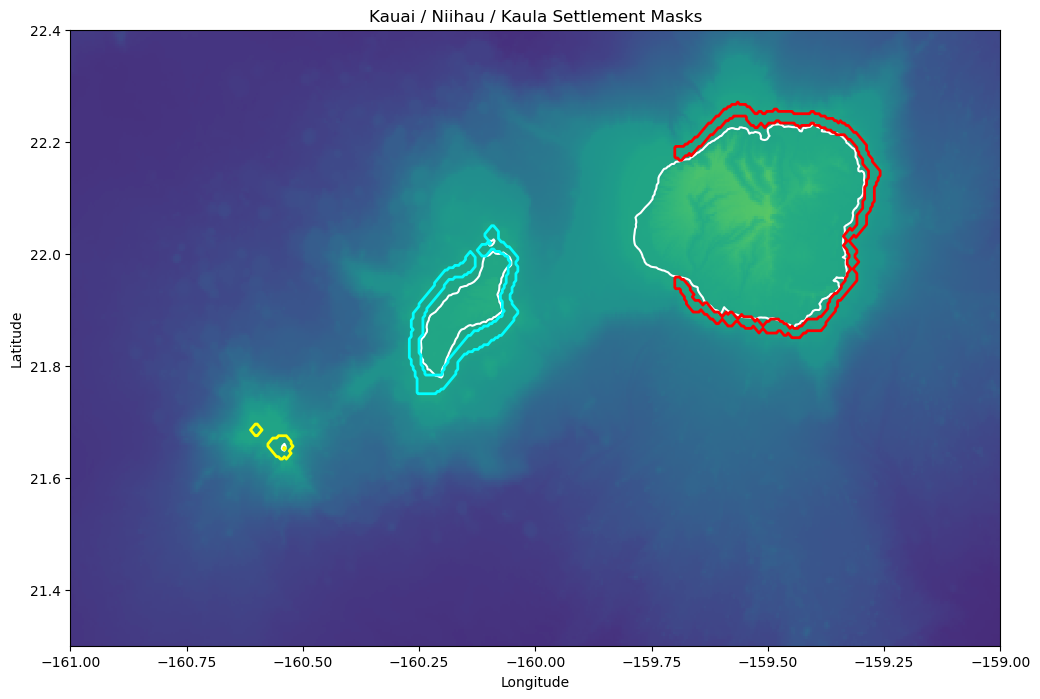

In [59]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 8))

# background bathymetry
plt.pcolormesh(
    lon_bathy,
    lat_bathy,
    depth,
    cmap="viridis",
    shading="auto"
)

# coastline
plt.contour(
    lon_bathy,
    lat_bathy,
    depth,
    levels=[0],
    colors="white",
    linewidths=1.5
)

# west-side masks
plt.contour(
    lon_bathy,
    lat_bathy,
    region_masks["Kauai"],
    levels=[0.5],
    colors="red",
    linewidths=2
)

plt.contour(
    lon_bathy,
    lat_bathy,
    region_masks["Niihau"],
    levels=[0.5],
    colors="cyan",
    linewidths=2
)

plt.contour(
    lon_bathy,
    lat_bathy,
    region_masks["Kaula"],
    levels=[0.5],
    colors="yellow",
    linewidths=2
)

plt.xlim(-161.0, -159.0)
plt.ylim(21.3, 22.4)

plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Kauai / Niihau / Kaula Settlement Masks")
plt.show()

In [ ]:
print("Niihau vs Kauai overlap:", island_polygons["Niihau"].intersects(island_polygons["Kauai"]))
print("Niihau vs Kaula overlap:", island_polygons["Niihau"].intersects(island_polygons["Kaula"]))
print("Niihau vs Oahu overlap:", island_polygons["Niihau"].intersects(island_polygons["Oahu"]))
print("Niihau vs Maui_Nui overlap:", island_polygons["Niihau"].intersects(island_polygons["Maui_Nui"]))
print("Niihau vs Hawaii overlap:", island_polygons["Niihau"].intersects(island_polygons["Hawaii"]))

C:\Users\Trevell\AppData\Local\Temp\ipykernel_28452\1837152102.py:70: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()
C:\Users\Trevell\miniconda3\envs\oceanparcels310\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


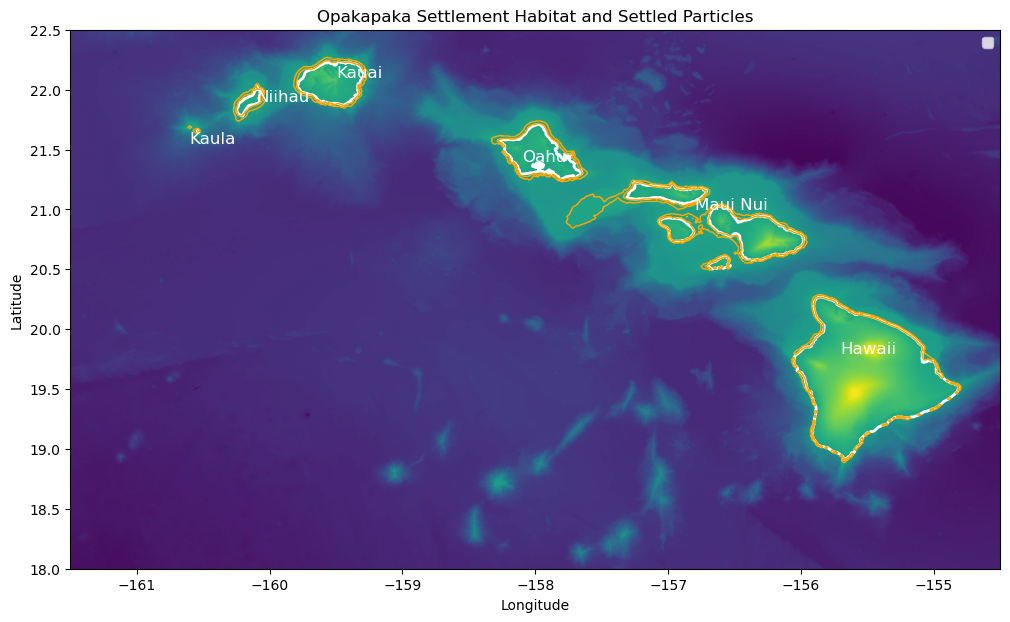

In [61]:
plt.figure(figsize=(12, 7))

# ------------------------------------------------
# BATHYMETRY BACKGROUND (ETOPO)
# ------------------------------------------------
plt.pcolormesh(
    lon_bathy,
    lat_bathy,
    depth,
    cmap="viridis",
    shading="gouraud"
)

# ------------------------------------------------
# ISLAND COASTLINES
# ------------------------------------------------
plt.contour(
    lon_bathy,
    lat_bathy,
    depth,
    levels=[0],
    colors="white",
    linewidths=2
)

# ------------------------------------------------
# HABITAT MASK (40-60 m + buffer)
# ------------------------------------------------
plt.contour(
    lon_bathy,
    lat_bathy,
    habitat_mask,
    levels=[0.5],
    colors="orange",
    linewidths=1
)

# ------------------------------------------------
# SETTLED PARTICLES ONLY
# ------------------------------------------------
if "settled" in globals():
    settled_mask = (settled == 1) & np.isfinite(settle_lon) & np.isfinite(settle_lat)

    plt.scatter(
        settle_lon[settled_mask],
        settle_lat[settled_mask],
        s=3,
        color="yellow",
        label="Settled Particles"
    )

# ------------------------------------------------
# ISLAND REGION LABELS
# ------------------------------------------------
plt.text(-159.5, 22.1, "Kauai", color="white", fontsize=12)
plt.text(-160.1, 21.9, "Niihau", color="white", fontsize=12)
plt.text(-160.6, 21.55, "Kaula", color="white", fontsize=12)
plt.text(-158.1, 21.4, "Oahu", color="white", fontsize=12)
plt.text(-156.8, 21.0, "Maui Nui", color="white", fontsize=12)
plt.text(-155.7, 19.8, "Hawaii", color="white", fontsize=12)

# ------------------------------------------------
# FORMATTING
# ------------------------------------------------
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Opakapaka Settlement Habitat and Settled Particles")
plt.xlim(-161.5, -154.5)
plt.ylim(18.0, 22.5)
plt.legend()
plt.show()

#make a panguin bank polygon

In [69]:
matrix = pd.crosstab(df_conn.release, df_conn.settle)

print(matrix)

settle     0    1   2     3     4     5
release                                
0        292    0   0    63   480     8
1        148  154   0   180   113     0
2          8    4   0   486     0     0
3         90   52   0   166  1090   326
4        787  324  21  1599  5000  1245
5          0    0   6    82   726  4119
6        477   91   0   484   826   710


In [65]:
kaula_release_idx = [i for i, r in enumerate(release_region_names) if r == "Kaula"]
kaula_settle_ids = settle_region_id[kaula_release_idx]

print("Kaula releases settlement counts:")
unique, counts = np.unique(kaula_settle_ids[kaula_settle_ids >= 0], return_counts=True)
for u, c in zip(unique, counts):
    print(id_to_island[u], c)

Kaula releases settlement counts:
Kauai 8
Niihau 4
Oahu 486


C:\Users\Trevell\miniconda3\envs\oceanparcels310\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


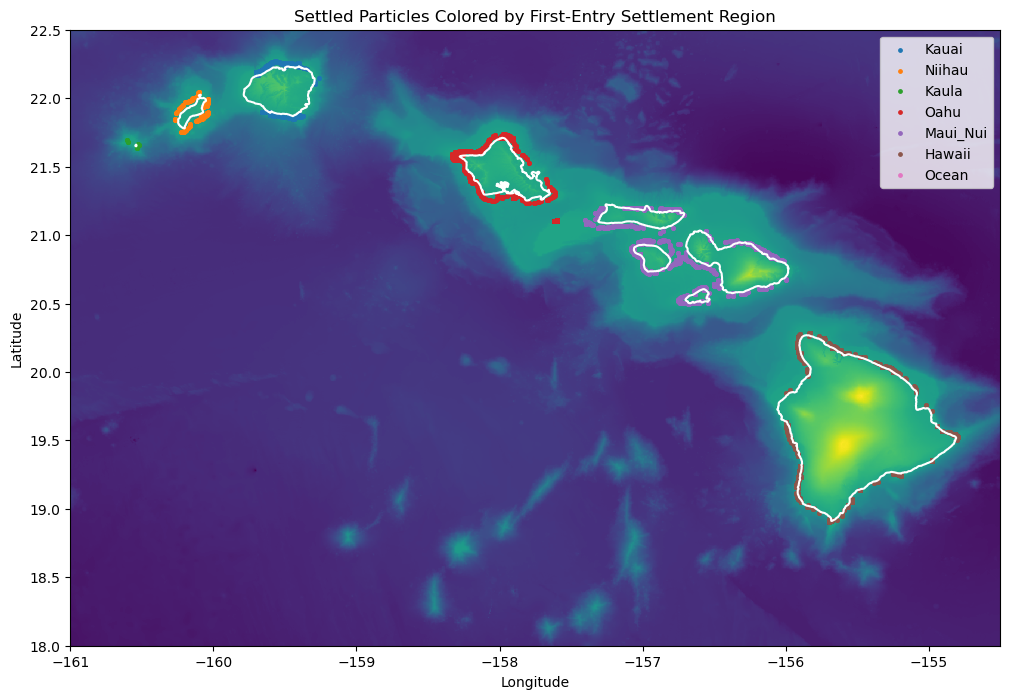

In [66]:
import matplotlib.pyplot as plt
import numpy as np

ds = xr.open_zarr("Opakapaka_first_entry_settlement.zarr")

settled = ds["settled"].isel(obs=-1).values
settle_region = ds["settle_region"].isel(obs=-1).values.astype(int)
settle_lon = ds["settle_lon"].isel(obs=-1).values
settle_lat = ds["settle_lat"].isel(obs=-1).values

mask = (settled == 1) & (settle_region >= 0)

plt.figure(figsize=(12, 8))

plt.pcolormesh(
    lon_bathy,
    lat_bathy,
    depth,
    cmap="viridis",
    shading="auto"
)

plt.contour(
    lon_bathy,
    lat_bathy,
    depth,
    levels=[0],
    colors="white",
    linewidths=1.5
)

for region_id, label in id_to_island.items():
    idx = mask & (settle_region == region_id)
    plt.scatter(
        settle_lon[idx],
        settle_lat[idx],
        s=6,
        label=label
    )

plt.xlim(-161.0, -154.5)
plt.ylim(18.0, 22.5)
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Settled Particles Colored by First-Entry Settlement Region")
plt.legend()
plt.show()

In [ ]:
import numpy as np

settle = ds["settle_region"].values
kill = ds["kill_reason"].values

print("Total particles:", settle.size)
print("Settled:", np.sum(settle >= 0))
print("Never settled:", np.sum(settle < 0))

In [ ]:
settle = ds["settle_region"].values

# look at final timestep only
final_settle = settle[:, -1]

print("Total particles:", final_settle.size)
print("Settled:", np.sum(final_settle >= 0))
print("Never settled:", np.sum(final_settle < 0))

In [ ]:
settle = ds["settle_region"].values

ever_settled = np.any(settle >= 0, axis=1)

print("Total particles:", ever_settled.size)
print("Ever settled:", np.sum(ever_settled))
print("Never settled:", np.sum(~ever_settled))

In [ ]:
print("Habitat min:", np.min(fieldset.habitat.data))
print("Habitat max:", np.max(fieldset.habitat.data))

In [ ]:
import xarray as xr

ds = xr.open_zarr("Opakapaka_test_run_fixed.zarr")

traj_lon = ds["lon"].values
traj_lat = ds["lat"].values

In [ ]:
import xarray as xr

ds = xr.open_zarr("Opakapaka_test_run_fixed.zarr")

particle_lon = ds["lon"].values.flatten()
particle_lat = ds["lat"].values.flatten()

In [ ]:
import rasterio
import numpy as np

tif_path = r"C:\Users\Trevell\OneDrive\Documents\Opakapaka\roms\ETOPO_2022 (Bedrock; 15 arcseconds).tiff"

with rasterio.open(tif_path) as src:
    tif_data = src.read(1)
    extent = [src.bounds.left, src.bounds.right, src.bounds.bottom, src.bounds.top]

In [ ]:
plt.figure(figsize=(7,6))
plt.scatter(release_lons, release_lats, s=0.4, alpha=0.25, label="Release (ocean only)")
plt.scatter(pset.lon, pset.lat, s=0.6, alpha=0.9, label="After 70 day")
plt.legend(); plt.title("Opakapaka dispersal — june 1 - october 1 (2009 ROMS)")
plt.xlabel("Longitude"); plt.ylabel("Latitude"); plt.show()



In [ ]:
plt.figure(figsize=(8,8))
plt.scatter(ds["lon"].values.flatten(),
            ds["lat"].values.flatten(),
            s=0.2, alpha=0.2)

plt.title("All particle trajectories")
plt.show()

In [ ]:
# start_time and end_time are in seconds (float), not datetime
print("RUN start_time (sec):", start_time)
print("RUN end_time   (sec):", end_time)

runtime_seconds = end_time - start_time
print("RUN runtime seconds:", runtime_seconds)
print("RUN runtime days:", runtime_seconds / 86400.0)  # 86400 sec per day

In [ ]:
import xarray as xr
import numpy as np

ds = xr.open_zarr("Opakapaka_test_run_fixed.zarr")
final_kill = ds["kill_reason"].isel(obs=-1).values

alive = np.sum((final_kill == 0) | np.isnan(final_kill))
killed_land = np.sum(final_kill == 1)
killed_oob = np.sum(final_kill == 2)

print("=== PARTICLE SUMMARY ===")
print("Alive:", alive)
print("Killed on land:", killed_land)
print("Killed out of bounds:", killed_oob)
print("Total:", alive + killed_land + killed_oob)

In [ ]:
import xarray as xr

ds = xr.open_zarr("Opakapaka_test_run_fixed.zarr")

settled_particles = (ds.settled == 1).sum().item()

print("Total particles settled:", settled_particles)

In [ ]:
print("release sites:", len(release_lons))
print("total particles released:", int(release_counts.sum()))


In [ ]:
print("Has Kh_zonal:", hasattr(fieldset, "Kh_zonal"))
print("Has Kh_meridional:", hasattr(fieldset, "Kh_meridional"))


In [ ]:
import xarray as xr
ds = xr.open_zarr("Opakapaka_2015_JunSep_weekly.zarr")

lon_final = ds["lon"].isel(obs=-1)
lat_final = ds["lat"].isel(obs=-1)

print(lon_final.shape, lat_final.shape)
